# Exploring AAPL Stock Data with Pandas and Matplotlib

In this assignment, you will use `AAPL.csv` to practice basic data inspection, summary statistics, and plotting with Pandas and Matplotlib.

The dataset contains daily Apple stock price data with the columns `date`, `adj_close`, `close`, `high`, `low`, `open`, `volume`, and `symbol`.

For each exercise, write your code between the `# <START>` and `# <END>` comments.


In [6]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')


## Exercise 1: Load and Inspect the Dataset

Read `AAPL.csv` into a DataFrame named `df`. Then display:

- The first 10 rows
- The shape of the dataset
- The column names
- The data types of each column


In [10]:
import pandas as pd
# <START>
# Read AAPL.csv into df
df=pd.read_csv("/AAPL.csv")


# Display the first 10 rows

print(df.head(10))
# Display the shape, columns, and data types
print("shape",df.shape)
print("columns",df.columns)
print("data types",df.dtypes)
# <END>

         date  adj_close      close       high        low       open  \
0  2015-01-02  24.192606  27.332500  27.860001  26.837500  27.847500   
1  2015-01-05  23.511055  26.562500  27.162500  26.352501  27.072500   
2  2015-01-06  23.513268  26.565001  26.857500  26.157499  26.635000   
3  2015-01-07  23.842981  26.937500  27.049999  26.674999  26.799999   
4  2015-01-08  24.759077  27.972500  28.037500  27.174999  27.307501   
5  2015-01-09  24.785631  28.002501  28.312500  27.552500  28.167500   
6  2015-01-12  24.174902  27.312500  28.157499  27.200001  28.150000   
7  2015-01-13  24.389544  27.555000  28.200001  27.227501  27.857500   
8  2015-01-14  24.296606  27.450001  27.622499  27.125000  27.260000   
9  2015-01-15  23.637186  26.705000  27.514999  26.665001  27.500000   

      volume symbol  
0  212818400   AAPL  
1  257142000   AAPL  
2  263188400   AAPL  
3  160423600   AAPL  
4  237458000   AAPL  
5  214798000   AAPL  
6  198603200   AAPL  
7  268367600   AAPL  
8  195826

## Exercise 2: Convert and Sort Dates

The `date` column is currently read as text. Convert it to a datetime column, sort the rows by date, and reset the index.

After sorting, display the earliest date and latest date in the dataset.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [12]:
# <START>
# Convert date column to datetime
df['date']=pd.to_datetime(df['date'])

# Sort by date and reset the index
df=df.sort_values('date').reset_index(drop=True)
# Display the first and last dates
print('fist date',df['date'].min())
print('last date',df['date'].max())
# <END>


fist date 2015-01-02 00:00:00
last date 2026-05-14 00:00:00


## Exercise 3: Summary Statistics

Find the mean, standard deviation, highest value, and lowest value for these numerical columns:

- `open`
- `high`
- `low`
- `close`
- `adj_close`
- `volume`

Store the result in a variable named `summary_stats` and display it.


In [13]:
numeric_cols = ['open', 'high', 'low', 'close', 'adj_close', 'volume']

# <START>
# Calculate mean, standard deviation, minimum, and maximum
summary_stats=df[numeric_cols].agg(['mean','std','min','max'])
# Display summary_stats
print(summary_stats)
# <END>


            open        high         low       close   adj_close        volume
mean  113.560275  114.790064  112.422560  113.659821  111.213828  1.093330e+08
std    77.639929   78.469748   76.889401   77.717700   78.157844  6.794444e+07
min    22.500000   22.917500   22.367500   22.584999   20.565870  1.791060e+07
max   299.820007  300.920013  295.380005  298.869995  298.869995  6.488252e+08


## Exercise 4: Highest and Lowest Adjusted Close

Find the row where Apple had the highest `adj_close` price and the row where it had the lowest `adj_close` price.

Display the `date`, `adj_close`, and `volume` for both rows.


In [17]:
# <START>
# Find the index of the highest and lowest adjusted close values
max=df['adj_close'].idxmax()
min=df['adj_close'].idxmin()

# Select date, adj_close, and volume for both rows
highest=df.loc[max,['date','adj_close','volume']]
lowest=df.loc[min,['date','adj_close','volume']]
print('Highest adjusted close:')
print(highest)
print('Lowest adjusted close:')
print(lowest)
# <END>


Highest adjusted close:
date         2026-05-13 00:00:00
adj_close             298.869995
volume                  52684300
Name: 2856, dtype: object
Lowest adjusted close:
date         2016-05-12 00:00:00
adj_close               20.56587
volume                 305258800
Name: 342, dtype: object


## Exercise 5: Plot Date vs Adjusted Close

Create a line plot showing how `adj_close` changes over time.

Your plot should include:

- Figure size `(12, 5)`
- A blue line
- Title: `AAPL Adjusted Close Price Over Time`
- X-axis label: `Date`
- Y-axis label: `Adjusted Close Price`


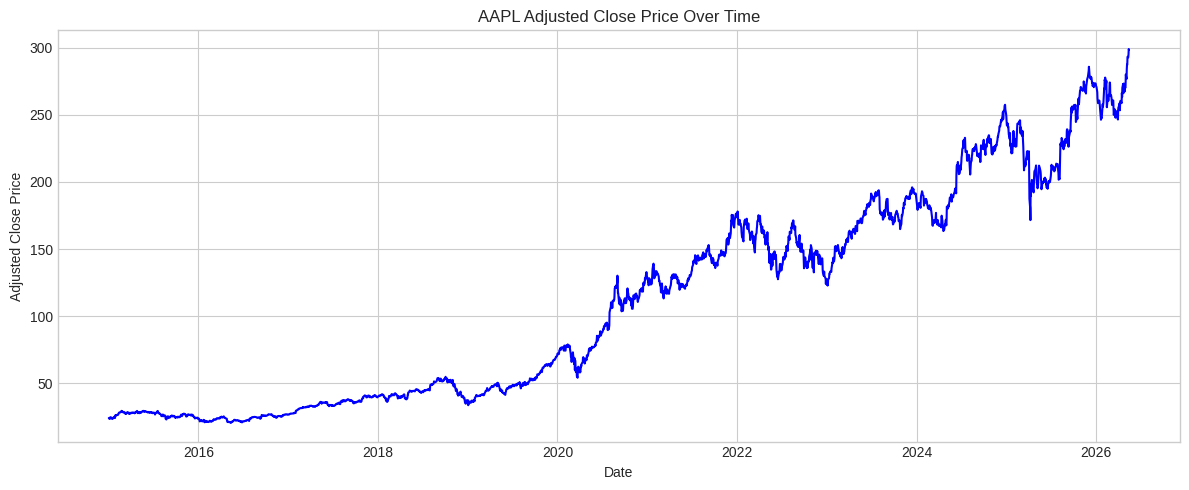

In [20]:
# <START>
plt.figure(figsize=(12,5))
plt.plot(df['date'],df['adj_close'],color='blue')
plt.title('AAPL Adjusted Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.tight_layout()
plt.show()
# <END>


## Exercise 6: Plot Trading Volume Over Time

Create a line plot for `volume` over time.

Your plot should include:

- Figure size `(12, 5)`
- A purple line
- Title: `AAPL Trading Volume Over Time`
- X-axis label: `Date`
- Y-axis label: `Volume`


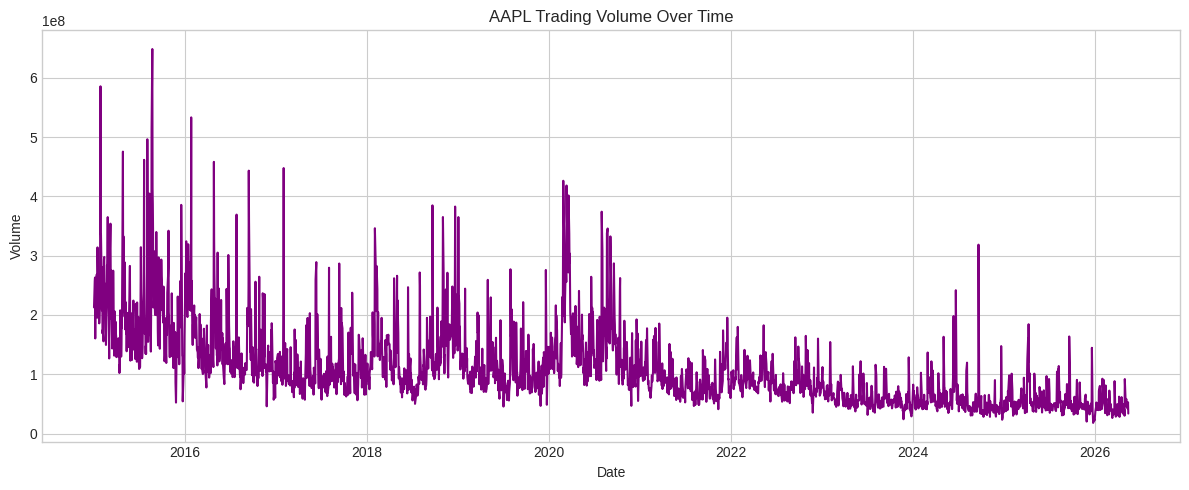

In [23]:
# <START>
plt.figure(figsize=(12,5))
plt.plot(df['date'],df['volume'],color='purple')
plt.title('AAPL Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()
# <END>


## Exercise 7: Top 10 Highest Volume Days

Find the 10 days with the highest trading volume and store them in `top_volume_days`.

Then create a bar chart with:

- `date` on the X-axis
- `volume` on the Y-axis
- Title: `Top 10 AAPL Trading Volume Days`
- Rotated X-axis labels so the dates are readable


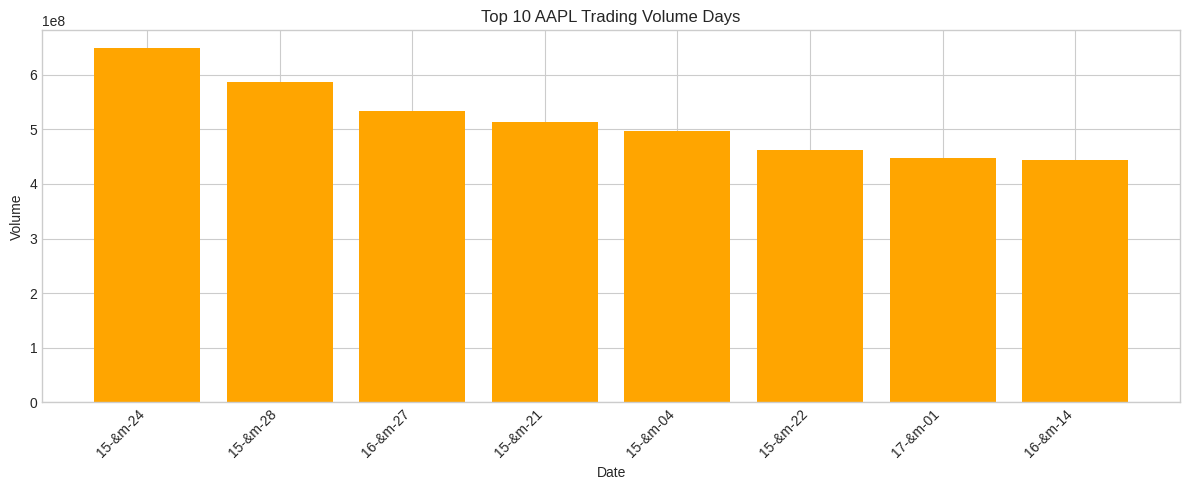

In [25]:
# <START>
# Find the 10 highest volume days
top_volume_days=df.nlargest(10,'volume')
# Plot the result
# plt.figure(figsize=(12, 5))
plt.figure(figsize=(12,5))
# plt.bar(top_volume_days['date'].dt.strftime('%Y-%m-%d'), top_volume_days['volume'], color='orange')
plt.bar(top_volume_days['date'].dt.strftime('%y-&m-%d'),top_volume_days['volume'],color='orange')
# plt.title('Top 10 AAPL Trading Volume Days')
plt.title('Top 10 AAPL Trading Volume Days')
# plt.xlabel('Date')
plt.xlabel('Date')
# plt.ylabel('Volume')
plt.ylabel('Volume')
# plt.xticks(rotation=45, ha='right')
plt.xticks(rotation=45,ha='right')
# plt.tight_layout()
plt.tight_layout()
# plt.show()
plt.show()
# <END>


## Exercise 8: Moving Average Plot

Create two new columns:

- `ma_20`: 20-day moving average of `adj_close`
- `ma_50`: 50-day moving average of `adj_close`

Then plot `adj_close`, `ma_20`, and `ma_50` on the same graph.


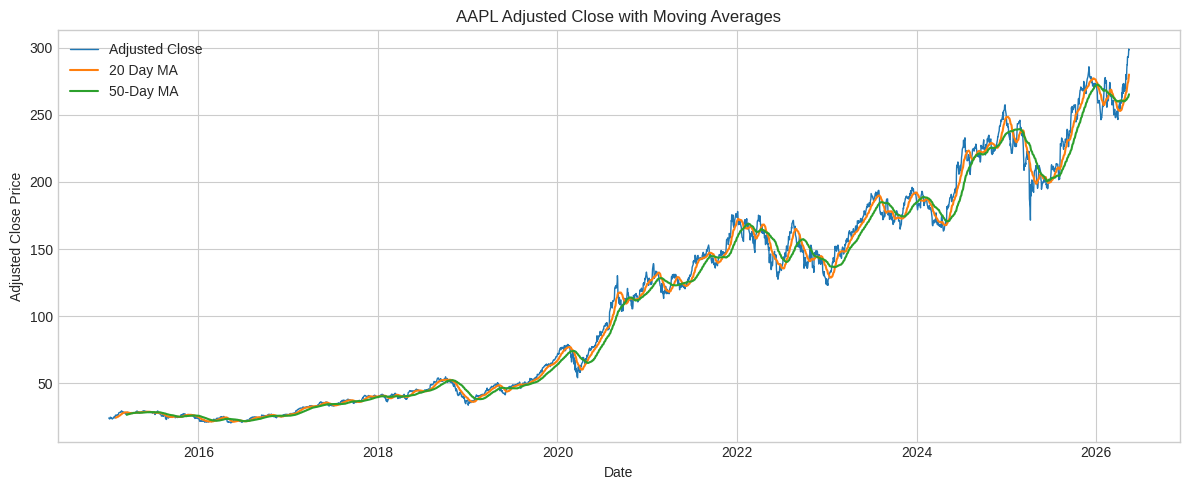

In [28]:
# <START>
# Calculate moving averages
df['ma_20']=df['adj_close'].rolling(window=20).mean()
df['ma_50']=df['adj_close'].rolling(window=50).mean()
# Plot adjusted close and moving averages
# plt.figure(figsize=(12, 5))
plt.figure(figsize=(12,5))
# plt.plot(df['date'], df['adj_close'], label='Adjusted Close', linewidth=1)
plt.plot(df['date'],df['adj_close'],label=['Adjusted Close'],linewidth=1)
# plt.plot(df['date'], df['ma_20'], label='20-Day MA', linewidth=1.5)
plt.plot(df['date'],df['ma_20'],label='20 Day MA',linewidth=1.5)
# plt.plot(df['date'], df['ma_50'], label='50-Day MA', linewidth=1.5)
plt.plot(df['date'],df['ma_50'],label='50-Day MA',linewidth=1.5)
# plt.title('AAPL Adjusted Close with Moving Averages')
plt.title('AAPL Adjusted Close with Moving Averages')
# plt.xlabel('Date')
plt.xlabel('Date')
# plt.ylabel('Adjusted Close Price')
plt.ylabel('Adjusted Close Price')
# plt.legend()
plt.legend()
# plt.tight_layout()
plt.tight_layout()
# plt.show()
plt.show()
# <END>


## Exercise 9: Relationship Between Daily Range and Volume

Create a new column named `daily_range` using:

`daily_range = high - low`

Then make a scatter plot with `daily_range` on the X-axis and `volume` on the Y-axis.


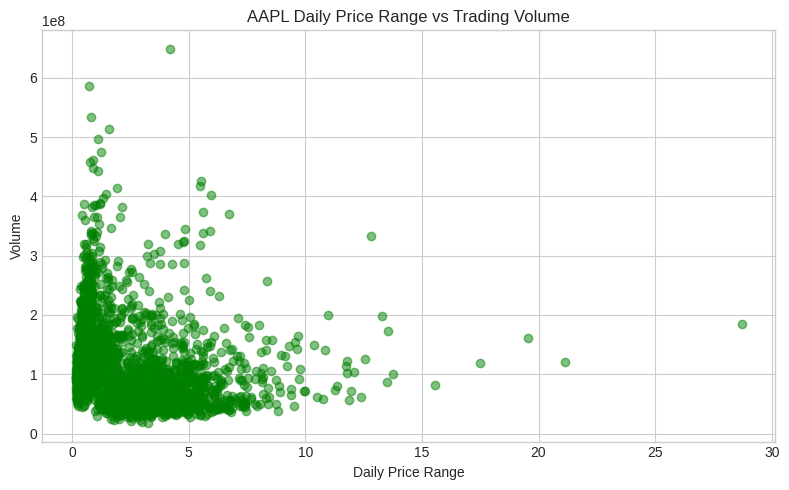

In [29]:
# <START>
# Calculate daily range
df['daily_range']=df['high']-df['low']
# Create scatter plot
# plt.figure(figsize=(8, 5))
plt.figure(figsize=(8,5))
# plt.scatter(df['daily_range'], df['volume'], alpha=0.5, color='green')
plt.scatter(df['daily_range'],df['volume'],alpha=0.5,color='green')
# plt.title('AAPL Daily Price Range vs Trading Volume')
plt.title('AAPL Daily Price Range vs Trading Volume')
# plt.xlabel('Daily Price Range')
plt.xlabel('Daily Price Range')
# plt.ylabel('Volume')
plt.ylabel('Volume')
# plt.tight_layout()
plt.tight_layout()
# plt.show()
plt.show()
# <END>


## Bonus Exercise: Monthly Average Adjusted Close

Group the data by month and calculate the average `adj_close` for each month. Plot the monthly averages as a line plot.

Hint: Use `df.set_index('date').resample('ME')`.


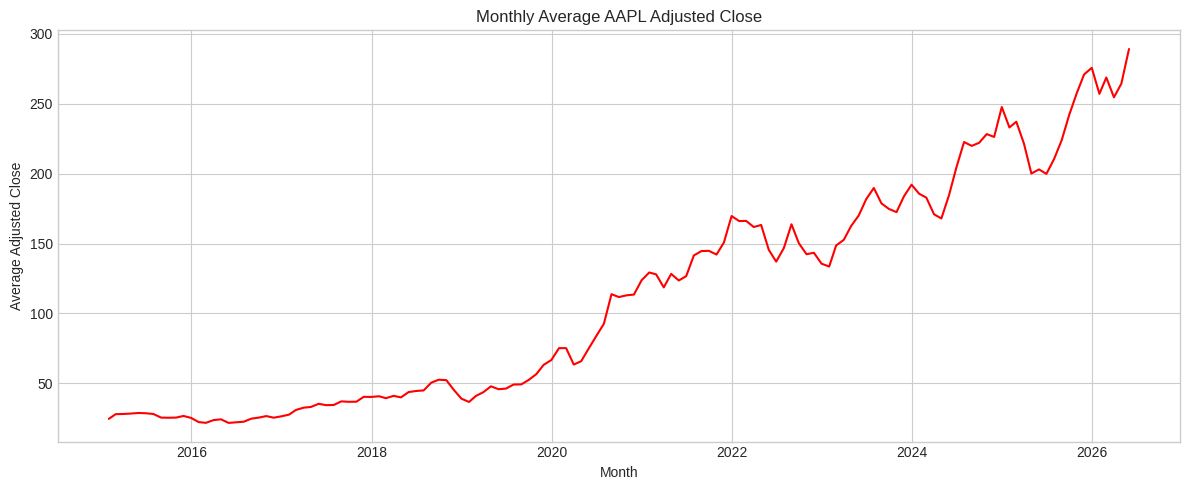

In [30]:
# <START>
# Calculate monthly average adjusted close
monthly_avg=df.set_index('date').resample('ME')['adj_close'].mean()
# Plot monthly average adjusted close
plt.figure(figsize=(12,5))
plt.plot(monthly_avg.index,monthly_avg.values,color='red',linewidth=1.5)
plt.title('Monthly Average AAPL Adjusted Close')
plt.xlabel('Month')
plt.ylabel('Average Adjusted Close')
plt.tight_layout()
plt.show()
# <END>
